# PCA
To identify important features in the dataset we will check how much of the variance in the dataset can be explained by the features.
We will look for informative numeric features in the dataset.

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as ss
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import pingouin as png

# new
import factor_analyzer as fa
import sklearn.decomposition as skd


%run utils.py

In [2]:
full_df = pd.read_csv("prepared_dataset.csv") # load the csv file prepared in a2_data_description.ipynb

full_df.drop(columns=['Unnamed: 0'], inplace=True)
print(full_df.head())

# identify numeric variables for PCA
df = full_df.select_dtypes(include=['int64', 'float64'])
df.drop(columns=['Medu', 'Fedu'], inplace=True)
df

  school sex  age address famsize Pstatus  Medu  Fedu      Mjob      Fjob  \
0     GP   F   15       R     GT3       T     1     1   at_home     other   
1     GP   F   15       R     GT3       T     1     1     other     other   
2     GP   F   15       R     GT3       T     2     2   at_home     other   
3     GP   F   15       R     GT3       T     2     4  services    health   
4     GP   F   15       R     GT3       T     3     3  services  services   

   ... famrel freetime goout  Dalc Walc  health  absences.p  pG1  pG2 pG3  
0  ...      3        1     2     1    1       1           4   13   13  13  
1  ...      3        3     4     2    4       5           2   13   11  11  
2  ...      4        3     1     1    1       2           8   14   13  12  
3  ...      4        3     2     1    1       5           2   10   11  10  
4  ...      4        2     1     2    3       3           2   13   13  13  

[5 rows x 39 columns]


,age,failures.m,absences.m,mG1,mG2,mG3,traveltime,studytime,failures.p,famrel,freetime,goout,Dalc,Walc,health,absences.p,pG1,pG2,pG3
0,15,1,2,7,10,10,2,4,0,3,1,2,1,1,1,4,13,13,13
1,15,2,2,8,6,5,1,2,0,3,3,4,2,4,5,2,13,11,11
2,15,0,8,14,13,13,1,1,0,4,3,1,1,1,2,8,14,13,12
3,15,0,2,10,9,8,1,3,0,4,3,2,1,1,5,2,10,11,10
4,15,2,8,10,10,10,2,3,0,4,2,1,2,3,3,2,13,13,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
365,18,1,7,8,7,8,1,1,0,4,3,3,2,3,3,0,9,10,9
366,18,0,0,13,13,13,2,3,0,4,2,2,2,2,5,0,15,16,16
367,19,1,4,8,8,8,3,1,1,4,4,4,3,3,5,4,8,9,10
368,19,3,8,8,7,8,3,2,1,5,4,4,3,3,2,8,10,9,11


## Correlations: 

First a correlation will be done on the numeric variables to show which pairs are related.

In [3]:
corr = df.corr()
corr.style.background_gradient(cmap='coolwarm').format(precision=2)

,age,failures.m,absences.m,mG1,mG2,mG3,traveltime,studytime,failures.p,famrel,freetime,goout,Dalc,Walc,health,absences.p,pG1,pG2,pG3
age,1.00,0.15,0.12,-0.10,-0.17,-0.18,0.09,-0.01,0.26,0.04,0.01,0.16,0.13,0.16,-0.06,0.09,-0.10,-0.03,-0.06
failures.m,0.15,1.00,0.03,-0.39,-0.37,-0.37,0.11,-0.19,0.49,-0.07,0.08,0.14,0.14,0.16,0.08,0.17,-0.29,-0.35,-0.37
absences.m,0.12,0.03,1.00,-0.06,-0.05,0.02,-0.02,-0.08,0.04,-0.05,-0.05,0.07,0.15,0.20,-0.01,0.53,-0.07,-0.12,-0.11
mG1,-0.10,-0.39,-0.06,1.00,0.86,0.81,-0.10,0.14,-0.12,0.01,0.01,-0.14,-0.08,-0.11,-0.07,-0.15,0.58,0.60,0.56
mG2,-0.17,-0.37,-0.05,0.86,1.00,0.91,-0.16,0.11,-0.11,-0.03,-0.01,-0.16,-0.05,-0.07,-0.10,-0.18,0.54,0.58,0.52
mG3,-0.18,-0.37,0.02,0.81,0.91,1.00,-0.13,0.08,-0.11,0.04,0.01,-0.12,-0.04,-0.04,-0.06,-0.17,0.51,0.55,0.49
traveltime,0.09,0.11,-0.02,-0.10,-0.16,-0.13,1.00,-0.10,0.08,-0.01,-0.02,0.04,0.16,0.14,0.01,0.02,-0.19,-0.18,-0.15
studytime,-0.01,-0.19,-0.08,0.14,0.11,0.08,-0.10,1.00,-0.20,0.04,-0.13,-0.06,-0.19,-0.25,-0.08,-0.15,0.26,0.27,0.27
failures.p,0.26,0.49,0.04,-0.12,-0.11,-0.11,0.08,-0.20,1.00,-0.02,0.08,0.09,0.20,0.19,0.07,0.11,-0.29,-0.30,-0.34
famrel,0.04,-0.07,-0.05,0.01,-0.03,0.04,-0.01,0.04,-0.02,1.00,0.14,0.06,-0.09,-0.13,0.10,-0.06,-0.02,0.02,0.04


The correlation shows that the three Portuguese grade values are strongly related. The three Mathematics grade values are all related, but not as strongly as the Portuguese grades. Other notable relationships include the number maths failures relative to the number of portuguese failures, and the number of absences from class for portuguese and maths. Going out, Weekday alcohol consumption, are both related to weekend alcohol consumption.

## Assumption Checks
### Linear relationship between variables
The correlation heatmap indicates that there are linear relationships between variables.

### Sample size / weights
The sample size is 370. This is large enough not to require weighting.

### Correlations - Bartlett's test

In [4]:
sample_size = len(df)

sample_size

370

In [5]:
#bartlett's test

chi2, p = fa.calculate_bartlett_sphericity(df)
print(f'chi-squared: {chi2:.2f}\np-value: {p:.3f}')

chi-squared: 3441.54
p-value: 0.000


Bartlett's test is significant ($chi^2 = 3441.54$, *p* < .001), meaning that the assumption that correlations exist holds.

### Kaiser–Meyer–Olkin (KMO) measure of sampling adequacy

Kaiser's rule of thumb for assessing KMO values: 
- KMO > 0.9 marvelous
- in the 0.80s meritorious
- in the 0.70s middling
- in the 0.60s mediocre
- in the 0.50s miserable
- less than 0.5 unacceptable

In [6]:
fa.calculate_kmo(df)

(array([0.58613391, 0.82416394, 0.50382864, 0.88879332, 0.77972203,
        0.8007335 , 0.77504502, 0.85956059, 0.73516329, 0.39380931,
        0.62127013, 0.67686551, 0.7271518 , 0.67338994, 0.71924574,
        0.61821722, 0.86091286, 0.81031002, 0.87581249]),
 0.7869064507524798)

The overall KMO value of 0.787 indicates that the sampling adequacy is fine, even if some individual values are too low.

### Check the determinant

In [7]:
round(np.linalg.det(df.corr()),4)

0.0001

The determinant (0.0001) is greater than 0.00001, which means that the assumption is fulfilled.


### Check for outliers

In [8]:
outlier_inds = abs(scale(df)) > get_outlier_cv(len(df))
list(('column: ' + str(col), 
      'number of outliers: ' + str(outlier_inds[col].sum()), 
      df[col][outlier_inds[col]]) for col in df.columns[outlier_inds.sum() > 0])

[('column: age',
  'number of outliers: 1',
  330    22
  Name: age, dtype: int64),
 ('column: failures.m',
  'number of outliers: 15',
  19     3
  34     3
  43     3
  48     3
  143    3
  169    3
  204    3
  272    3
  277    3
  278    3
  281    3
  319    3
  327    3
  330    3
  368    3
  Name: failures.m, dtype: int64),
 ('column: absences.m',
  'number of outliers: 3',
  65     54
  139    56
  142    75
  Name: absences.m, dtype: int64),
 ('column: traveltime',
  'number of outliers: 8',
  47     4
  175    4
  177    4
  204    4
  269    4
  272    4
  320    4
  339    4
  Name: traveltime, dtype: int64),
 ('column: failures.p',
  'number of outliers: 11',
  143    3
  169    2
  254    2
  273    3
  278    3
  281    3
  305    2
  307    3
  319    2
  329    2
  330    3
  Name: failures.p, dtype: int64),
 ('column: Dalc',
  'number of outliers: 9',
  47     5
  180    5
  246    5
  250    5
  269    5
  292    5
  307    5
  330    5
  359    5
  Name: Dalc, dt

There are 15 outliers in the final portuguese grades. 

In [9]:
#check how far out the outliers lie
(1 - df['pG3'].mean())/df['pG3'].std()

-3.925073628890274

As the outliers are all within 4 standard deviations, we can perform the PCA.

### Perform PCA

First the variables are scaled so that their values are all in the same range and are not skewed by the difference between the scales of variables.

In [10]:
### Perform PCA

df_scaled = scale(df)
df_scaled.head(5)

,age,failures.m,absences.m,mG1,mG2,mG3,traveltime,studytime,failures.p,famrel,freetime,goout,Dalc,Walc,health,absences.p,pG1,pG2,pG3
0,-1.334558,1.015511,-0.441069,-1.163365,-0.197673,-0.100864,0.790176,2.307676,-0.270402,-1.026154,-2.257037,-0.989034,-0.539788,-1.002879,-1.820289,0.076138,0.338893,0.295981,0.151494
1,-1.334558,2.422774,-0.441069,-0.864445,-1.250031,-1.185738,-0.635996,-0.050998,-0.270402,-1.026154,-0.227623,0.783085,0.575975,1.321120,1.021512,-0.338142,0.338893,-0.515225,-0.527934
2,-1.334558,-0.391752,0.341643,0.929076,0.591596,0.550061,-0.635996,-1.230335,-0.270402,0.071178,-0.227623,-1.875094,-0.539788,-1.002879,-1.109838,0.904697,0.730738,0.295981,-0.188220
3,-1.334558,-0.391752,-0.441069,-0.266604,-0.460762,-0.534814,-0.635996,1.128339,-0.270402,0.071178,-0.227623,-0.989034,-0.539788,-1.002879,1.021512,-0.338142,-0.836642,-0.515225,-0.867648
4,-1.334558,2.422774,0.341643,-0.266604,-0.197673,-0.100864,0.790176,1.128339,-0.270402,0.071178,-1.242330,-1.875094,0.575975,0.546454,-0.399388,-0.338142,0.338893,0.295981,0.151494


In [11]:
print(len(df.columns))
pca = skd.PCA(n_components=len(df.columns))
pca.fit(df_scaled)

19


PCA(n_components=19)

In [12]:
print(f'Raw eigenvalues:\n {pca.explained_variance_}\n'\
      f'Proportion of explained variance:\n {pca.explained_variance_/pca.explained_variance_.sum()}')

Raw eigenvalues:
 [5.16282334 2.17846184 1.49617674 1.30743645 1.24063349 1.15479658
 0.99725705 0.90342866 0.86954584 0.75820257 0.68635736 0.59865228
 0.45802767 0.3912513  0.29388579 0.18623897 0.16024079 0.08128816
 0.07529512]
Proportion of explained variance:
 [0.27172754 0.11465589 0.07874614 0.06881244 0.0652965  0.06077877
 0.05248721 0.04754888 0.04576557 0.0399054  0.03612407 0.03150801
 0.02410672 0.02059217 0.01546767 0.00980205 0.00843373 0.00427832
 0.0039629 ]


From the proportion of explained variance values, we can see that the first principal component explains ~27% of the total variance in the dataset. The second only explains ~11%.

### Visualisation

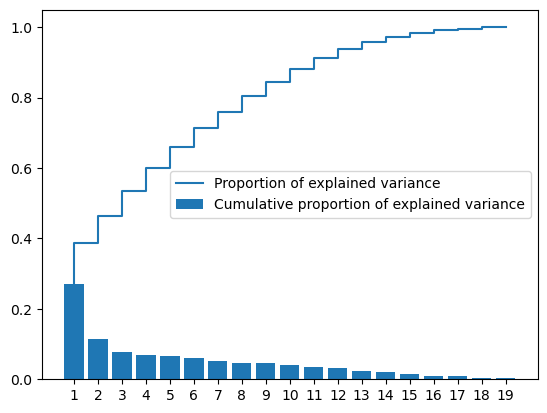

In [13]:
# plotting the explained variance
plt.bar(range(1, len(df.columns)+1), pca.explained_variance_/pca.explained_variance_.sum())
plt.step(range(1, len(df.columns)+1), np.cumsum(pca.explained_variance_/pca.explained_variance_.sum()))
plt.legend(['Proportion of explained variance', 'Cumulative proportion of explained variance'])
plt.xticks(range(1,20))
plt.show()

The first principal component is the most important for explaining the variance in the data.

Contributions by variables to first component

In [22]:
# First component : pca.components_[0]

component_contribs = pca.components_[0]
contribs_with_var_names = pd.Series(component_contribs, index=df.columns)

# Display contributions and variable names
print(contribs_with_var_names)

age           0.097342
failures.m    0.241999
absences.m    0.073782
mG1          -0.346939
mG2          -0.345690
mG3          -0.331197
traveltime    0.107813
studytime    -0.149541
failures.p    0.178303
famrel       -0.016367
freetime      0.062540
goout         0.123908
Dalc          0.162555
Walc          0.163061
health        0.079147
absences.p    0.130571
pG1          -0.364280
pG2          -0.383310
pG3          -0.368367
dtype: float64


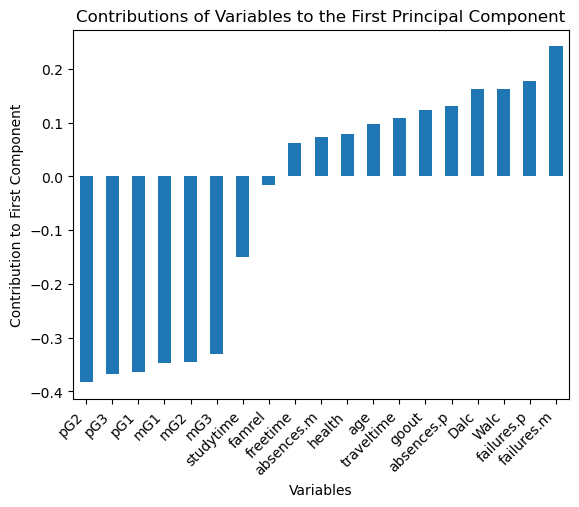

In [30]:
contribs_with_var_names.sort_values().plot(kind='bar') 
plt.title('Contributions of Variables to the First Principal Component')
plt.xlabel('Variables')
plt.ylabel('Contribution to First Component')
plt.xticks(rotation=45, ha='right') 
plt.show()

The first principal component captures 27% of the variance. 

From the plot above, it is clear that some variables contribute positively, and others negatively to the first principal component. The grade variables all have high negative contributions to the first principal component. The grades all have fairly similar levels of contribution.

Variables such as the number of failure in both subjects, the Weekend and Weekday alcohol consumption and absences all contribute positively to the first principal component. The highest contribution was from the previous Mathematics failures variable, followed by the previous portuguese failures.

This suggests that there is an inverse relationship between grades and  failures or alcohol consumption.

This would align with our initial hypothesis:
>Students who drink alcohol more frequently during the week are associated with worse grades.